In [2]:
from PIL import Image
import numpy as np
from matplotlib import pyplot as plt
import time

(480, 640, 3)


(-0.5, 639.5, 479.5, -0.5)

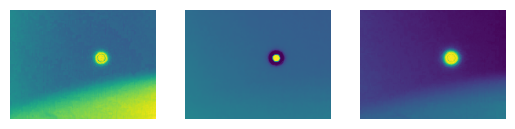

In [ ]:
image = Image.open('3cm_from_mirror/gaussian_3uW.jpg')
image_array = np.array(image)

print(image_array.shape)
plt.subplot(1,3 ,1)
plt.imshow(image_array[:, :, 0])
plt.axis("off")
plt.subplot(1,3 ,2)
plt.imshow(image_array[:, :, 1])
plt.axis("off")
plt.subplot(1,3 ,3)
plt.imshow(image_array[:, :, 2])
plt.axis("off")

In [8]:
from skimage.transform import resize
from skimage.io import imsave, imread
from scipy import ndimage
import scipy.optimize as opt
from scipy.ndimage import gaussian_filter


def twoD_Gaussian(xy, amplitude, xo, yo, sigma_x, sigma_y, offset):
    theta = 0
    x, y = xy
    xo = float(xo)
    yo = float(yo)    
    a = (np.cos(theta)**2)/(2*sigma_x**2) + (np.sin(theta)**2)/(2*sigma_y**2)
    b = -(np.sin(2*theta))/(4*sigma_x**2) + (np.sin(2*theta))/(4*sigma_y**2)
    c = (np.sin(theta)**2)/(2*sigma_x**2) + (np.cos(theta)**2)/(2*sigma_y**2)
    g = offset + amplitude*np.exp( - (a*((x-xo)**2) + 2*b*(x-xo)*(y-yo) 
                            + c*((y-yo)**2)))
    return g.ravel()

def curve_fitting(image_array):
    # curve fitting method
    imgR = image_array[:,:,0]
    imgG = image_array[:,:,1]
    imgB = image_array[:,:,2]
    image = (0.7 * imgR) + (0.2 * imgG) + (0.1 * imgB)


    img = image
    x = np.linspace(0, np.shape(img)[1], np.shape(img)[1])
    y = np.linspace(0, np.shape(img)[0], np.shape(img)[0])
    x, y = np.meshgrid(x,y)

    # Apply Gaussian filter using SciPy
    blurred_image = gaussian_filter(img, sigma=10)

    # print("blurred_image")
    # plt.imshow(blurred_image)
    # plt.show()
    max_index = np.argmax(blurred_image)
    max_index_2d = np.unravel_index(max_index, img.shape)
    # print('max_index', max_index_2d)

        
    # ~ initial_guess = (100,320,240,100,100,0)
    initial_guess = (100,max_index_2d[1],max_index_2d[0],100,100,0)
    # print('initial_guess', initial_guess)

    # print('try fit')
        
    popt, pcov = opt.curve_fit(twoD_Gaussian, (x, y), img.ravel(), p0=initial_guess, maxfev=2000)
    # print('fit', popt)
    err = np.sqrt(np.diagonal(pcov))
    # print('err', err)

    global x_center, y_center, x_sig, y_sig
        
    x_center = popt[1]
    y_center = popt[2]
    x_sig = abs(popt[3])
    y_sig = abs(popt[4])

    # plt.scatter(x_center, y_center, color="red", s=4)
    # plt.imshow(image)
    # plt.show()

    return x_center, y_center

In [ ]:
from PIL import Image
import numpy as np
from matplotlib import pyplot as plt

def find_centre_gaus(image_array):
    image_array_max = (image_array <= image_array.max()) & (image_array > (image_array.max() - image_array.max()/4))
    index_horizontal = np.array(range(0, image_array_max.shape[1]))
    image_array_weighted_horizontal = index_horizontal * image_array_max
    image_array_weighted_horizontal_filtered = image_array_weighted_horizontal[image_array_weighted_horizontal > 0]
    avg_horizontal = np.average(image_array_weighted_horizontal_filtered)
    # print("horizontal: ", avg_horizontal)

    index_vetical = np.array(range(0, image_array_max.shape[0]))
    image_array_weighted_vetical = index_vetical * image_array_max.transpose() # transposed to rotate 90 degrees
    image_array_weighted_vetical_filtered = image_array_weighted_vetical[image_array_weighted_vetical > 0]
    avg_vetical = np.average(image_array_weighted_vetical_filtered)
    # print("vertical: ", avg_vetical)

    print("image array")
    plt.imshow(image_array)
    plt.show()
    plt.figure()
    plt.scatter(avg_horizontal, avg_vetical, color="red", s=4)
    print("image array max threshold")
    plt.imshow(image_array_max)
    plt.show()

    return avg_horizontal, avg_vetical

def plot_img(image_array):
    # print(image_array.shape)
    plt.figure()
    plt.subplot(1,3 ,1)
    plt.subplots_adjust(wspace=0.4, hspace=0.4)
    plt.imshow(image_array[:, :, 0])
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis("off")
    plt.subplot(1,3 ,2)
    plt.imshow(image_array[:, :, 1])
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis("off")
    plt.subplot(1,3 ,3)
    plt.imshow(image_array[:, :, 2])
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis("off")
    plt.show()



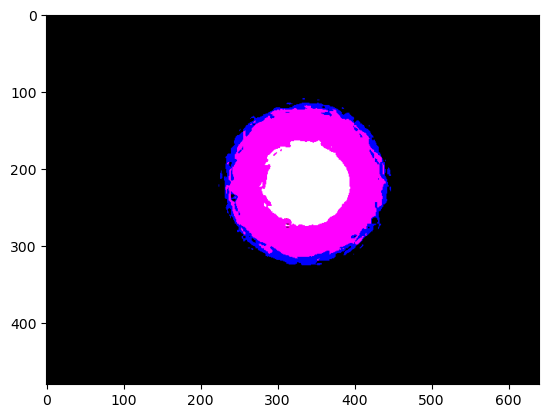

In [ ]:
image = Image.open('Power_exp_no_optic/6cm_from_mirror/gaussian_10uW.jpg')
image_array = np.array(image)

image_array_max = (image_array <= image_array.max()) & (image_array > (image_array.max() - image_array.max()/4))

plt.imshow(image_array_max.astype(float))

np.unique(image_array_max.astype(float))


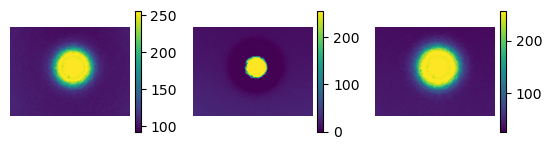

In [10]:
image = Image.open('6cm_from_mirror/gaussian_10uW.jpg')
image_array = np.array(image)

# image_array = image_array[100:300, 300:500, :]

plot_img(image_array=image_array)


single channel centre finding
x_center:  337.06635318704286   y_center:  219.2055381400209
x_curve:  337.1466747144016   y_curve:  219.60702917535312


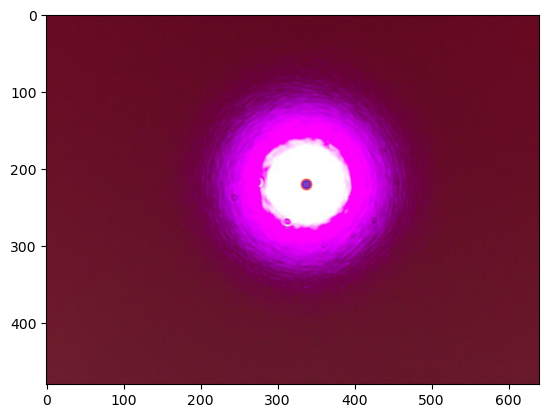

In [11]:
print("single channel centre finding")
x_curve, y_curve = curve_fitting(image_array=image_array)
x_center, y_center = find_centre_gaus(image_array=image_array[:,:,1])

print("x_center: ", x_center, "  y_center: ", y_center)
print("x_curve: ", x_curve, "  y_curve: ", y_curve)

plt.imshow(image_array)
plt.scatter(x_center, y_center, s=60, color="red", alpha=0.5)
plt.scatter(x_curve, y_curve, s=30, color="blue", alpha=0.5)
# print("weighted sum channel centre finding")
# find_centre_gaus(image_array=image)

# image = Image.open('gaussian_3uW.jpg')
# image_array = np.array(image)
# plot_img(image_array=image_array)
# find_centre_gaus(image_array=image_array[:,:,1])

# image = Image.open('gaussian_5uW.jpg')
# image_array = np.array(image)
# plot_img(image_array=image_array)
# find_centre_gaus(image_array=image_array[:,:,1])

# image = Image.open('gaussian_10uW.jpg')
# image_array = np.array(image)
# plot_img(image_array=image_array)
# find_centre_gaus(image_array=image_array[:,:,1])

# image = Image.open('gaussian_50uW.jpg')
# image_array = np.array(image)
# plot_img(image_array=image_array)
# find_centre_gaus(image_array=image_array[:,:,1])

# image = Image.open('gaussian_100uW.jpg')
# image_array = np.array(image)
# plot_img(image_array=image_array)
# find_centre_gaus(image_array=image_array[:,:,1])

# image = Image.open('gaussian_200uW.jpg')
# image_array = np.array(image)
# plot_img(image_array=image_array)
# find_centre_gaus(image_array=image_array[:,:,1])

# image = Image.open('gaussian_500uW.jpg')
# image_array = np.array(image)
# plot_img(image_array=image_array)
# find_centre_gaus(image_array=image_array[:,:,1])



In [12]:
import numpy as np
test = np.array([[0,0,1], [0,1,1], [1,1,1], [1, 0, 0]])
print(test)

index_vertical = np.array(range(0, test.shape[1]))
print()
print(index_vertical)
print()
print(index_vertical * test)

print()
print("--------------------")
index_horizontal = np.array(range(0, test.shape[0]))
print(index_horizontal)
test2 = index_horizontal * test.transpose()
print()
print(test2.transpose())


[[0 0 1]
 [0 1 1]
 [1 1 1]
 [1 0 0]]

[0 1 2]

[[0 0 2]
 [0 1 2]
 [0 1 2]
 [0 0 0]]

--------------------
[0 1 2 3]

[[0 0 0]
 [0 1 1]
 [2 2 2]
 [3 0 0]]


6cm_from_mirror/gaussian_3uW.jpg


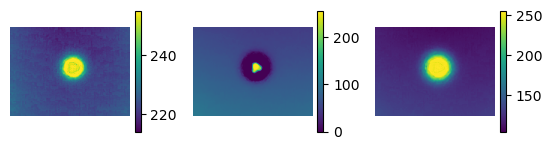

x_mean:  336.86375838926176   y_mean:  220.87046979865772  time: 0.0024
x_curve:  337.5612054696716   y_curve:  221.44864918378732  time: 0.53


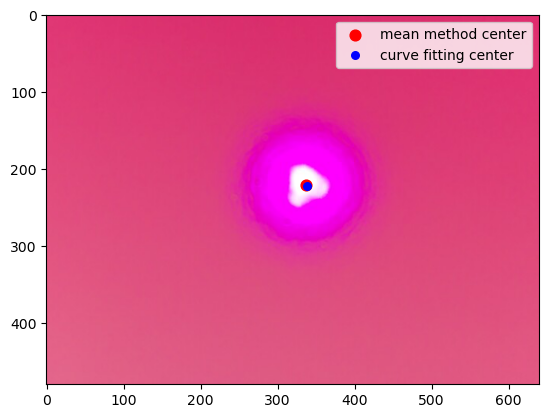

---------------------
6cm_from_mirror/gaussian_5uW.jpg


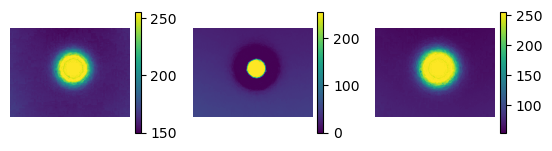

x_mean:  336.9702863317126   y_mean:  220.92666126418152  time: 0.0019
x_curve:  337.1495968367506   y_curve:  220.96737455306027  time: 0.48


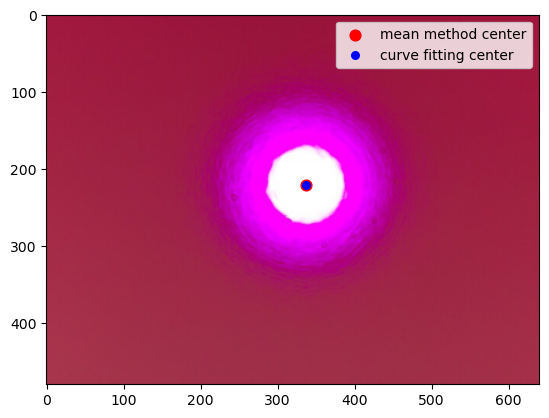

---------------------
6cm_from_mirror/gaussian_6uW.jpg


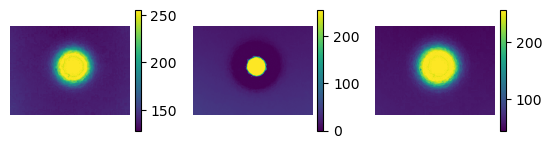

x_mean:  337.1273698943886   y_mean:  220.7289731518005  time: 0.002
x_curve:  337.21685186275784   y_curve:  220.57686672572328  time: 0.48


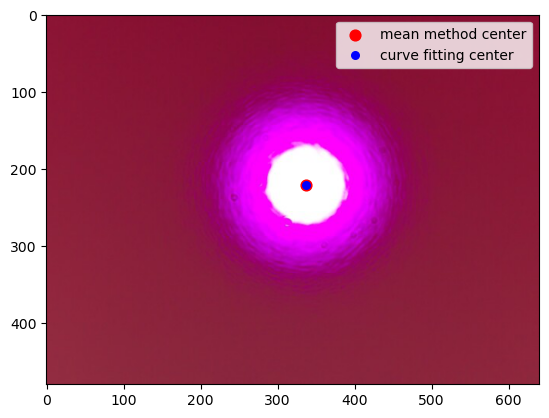

---------------------
6cm_from_mirror/gaussian_10uW.jpg


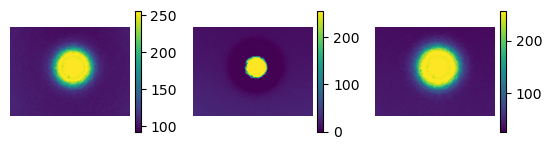

x_mean:  337.06635318704286   y_mean:  219.2055381400209  time: 0.0017
x_curve:  337.1466747144016   y_curve:  219.60702917535312  time: 0.52


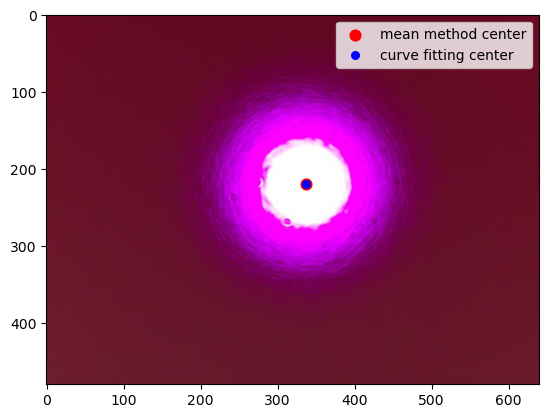

---------------------
6cm_from_mirror/gaussian_13uW.jpg


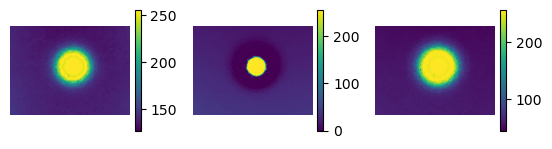

x_mean:  337.13384223918575   y_mean:  220.69643765903308  time: 0.0025
x_curve:  337.1966447274303   y_curve:  220.57406434949974  time: 0.5


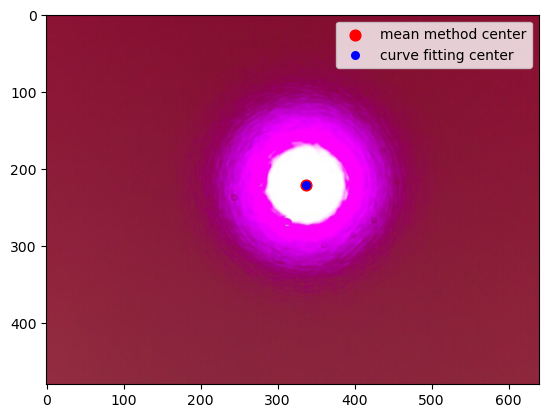

---------------------
6cm_from_mirror/gaussian_50uW.jpg


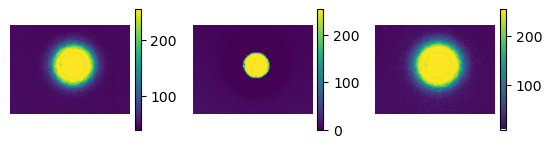

x_mean:  337.60701199798837   y_mean:  219.95028378475465  time: 0.0019
x_curve:  338.0741818324901   y_curve:  218.9196570198962  time: 0.54


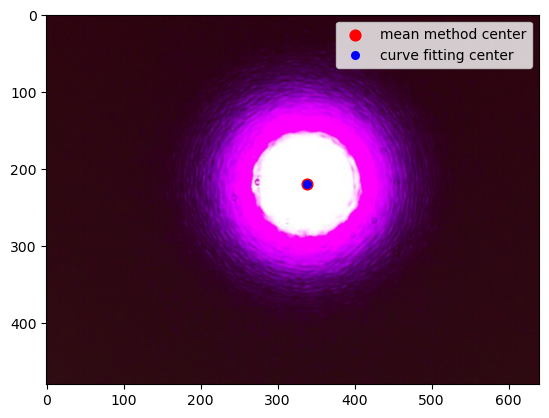

---------------------
6cm_from_mirror/gaussian_100uW.jpg


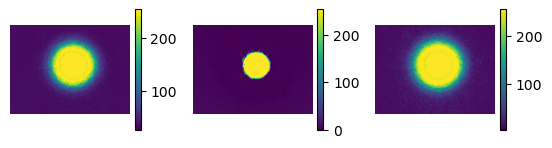

x_mean:  337.76839322801936   y_mean:  219.88658820567687  time: 0.0019
x_curve:  337.88484116592815   y_curve:  218.5292489124683  time: 0.44


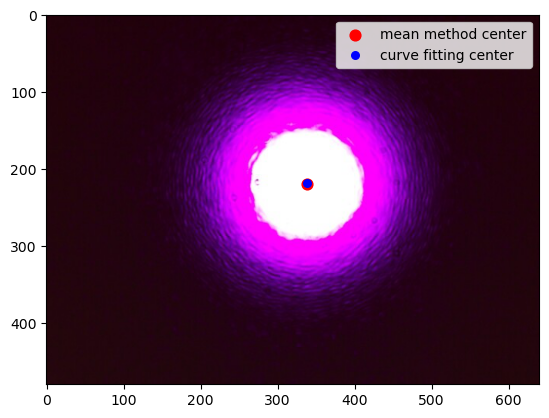

---------------------
6cm_from_mirror/gaussian_150uW.jpg


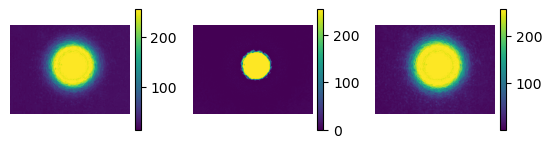

x_mean:  336.29215561593156   y_mean:  221.00635874906064  time: 0.0017
x_curve:  336.81643712027136   y_curve:  219.77919866928866  time: 0.41


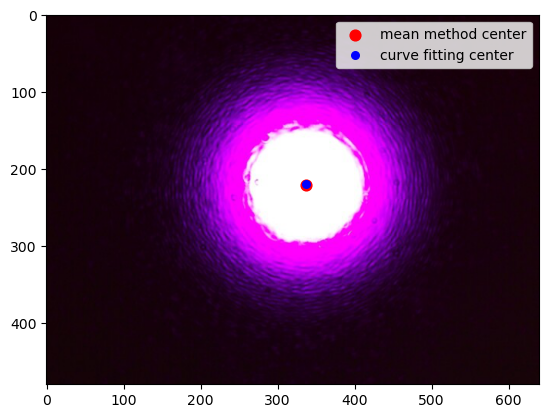

---------------------
6cm_from_mirror/gaussian_200uW.jpg


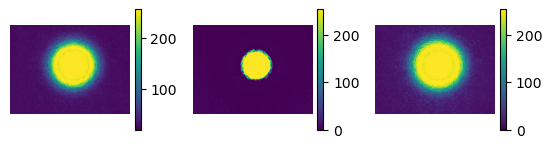

x_mean:  336.9375878093591   y_mean:  218.54301307683994  time: 0.0019
x_curve:  337.79893314482405   y_curve:  218.2780790346654  time: 0.5


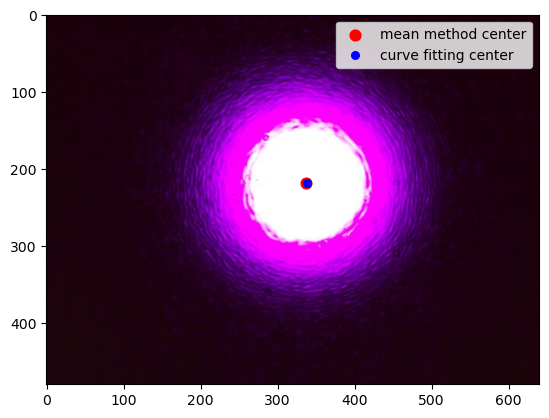

---------------------
6cm_from_mirror/gaussian_500uW.jpg


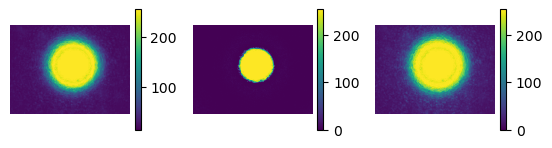

x_mean:  338.2447687779704   y_mean:  218.9710518888844  time: 0.0021
x_curve:  337.64992174178593   y_curve:  217.964948042302  time: 0.42


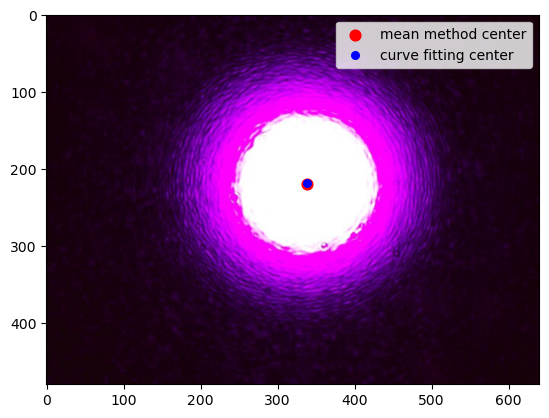

---------------------


In [13]:
img_path_list = [
    "gaussian_3uW.jpg",
    "gaussian_5uW.jpg",
    "gaussian_6uW.jpg",
    "gaussian_10uW.jpg",
    "gaussian_13uW.jpg",
    "gaussian_50uW.jpg",
    "gaussian_100uW.jpg",
    "gaussian_150uW.jpg",
    "gaussian_200uW.jpg",
    "gaussian_500uW.jpg"
]

# 6cm
for img_path in img_path_list:
    print(f"6cm_from_mirror/{img_path}")
    image = Image.open(f"6cm_from_mirror/{img_path}")
    image_array = np.array(image)
    plot_img(image_array=image_array)

    start_curve = time.perf_counter()
    x_curve, y_curve = curve_fitting(image_array=image_array)
    end_curve = time.perf_counter()

    start_mean = time.perf_counter()
    x_mean, y_mean = find_centre_gaus(image_array=image_array[:,:,1])
    end_mean = time.perf_counter()
    print("x_mean: ", x_mean, "  y_mean: ", y_mean, f" time: {end_mean - start_mean:.2}")
    print("x_curve: ", x_curve, "  y_curve: ", y_curve, f" time: {end_curve - start_curve:.2}")

    plt.imshow(image_array)
    plt.scatter(x_mean, y_mean, s=60, color="red", alpha=1, label="mean method center")
    plt.scatter(x_curve, y_curve, s=30, color="blue", alpha=1, label="curve fitting center")
    plt.legend()
    plt.show()
    print("---------------------")
    

3cm_from_mirror/gaussian_3uW.jpg


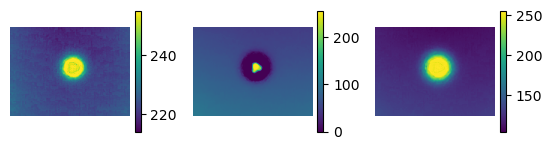

x_mean:  336.86375838926176   y_mean:  220.87046979865772  time: 0.0024
x_curve:  337.5612054696716   y_curve:  221.44864918378732  time: 0.46


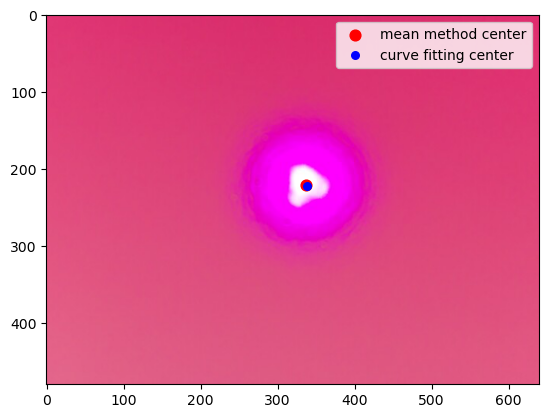

---------------------
3cm_from_mirror/gaussian_5uW.jpg


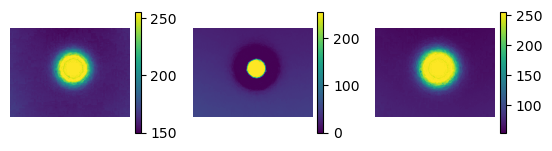

x_mean:  336.9702863317126   y_mean:  220.92666126418152  time: 0.002
x_curve:  337.1495968367506   y_curve:  220.96737455306027  time: 0.4


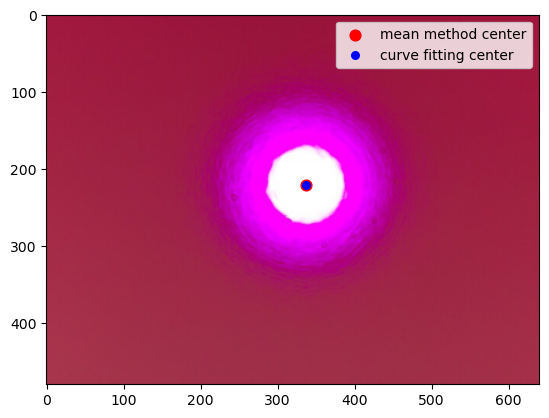

---------------------
3cm_from_mirror/gaussian_6uW.jpg


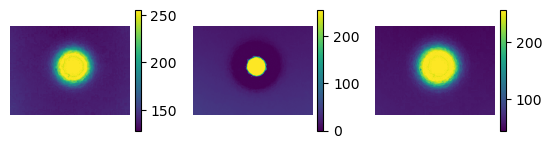

x_mean:  337.1273698943886   y_mean:  220.7289731518005  time: 0.0023
x_curve:  337.21685186275784   y_curve:  220.57686672572328  time: 0.49


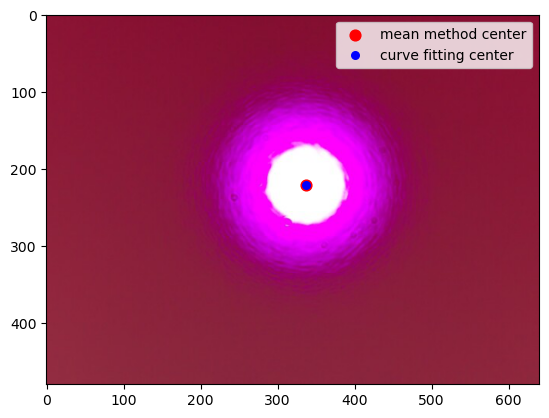

---------------------
3cm_from_mirror/gaussian_10uW.jpg


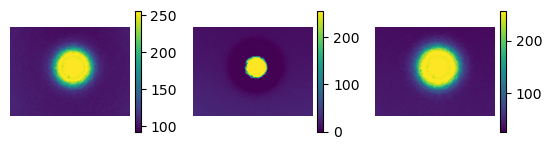

x_mean:  337.06635318704286   y_mean:  219.2055381400209  time: 0.0021
x_curve:  337.1466747144016   y_curve:  219.60702917535312  time: 0.54


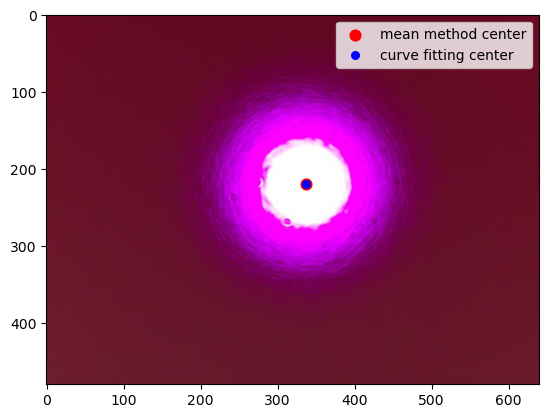

---------------------
3cm_from_mirror/gaussian_13uW.jpg


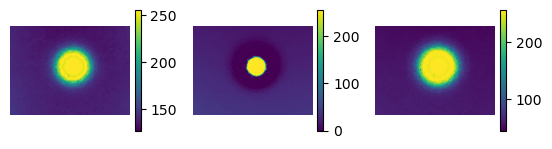

x_mean:  337.13384223918575   y_mean:  220.69643765903308  time: 0.0017
x_curve:  337.1966447274303   y_curve:  220.57406434949974  time: 0.46


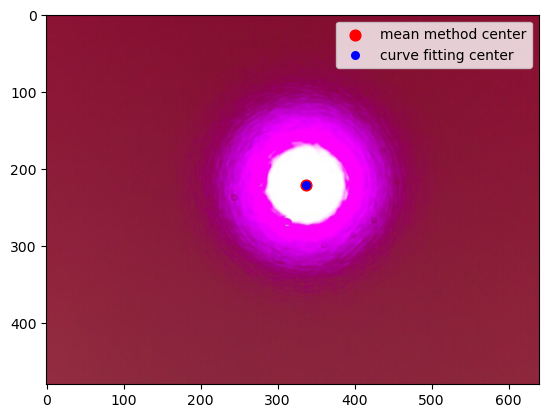

---------------------
3cm_from_mirror/gaussian_50uW.jpg


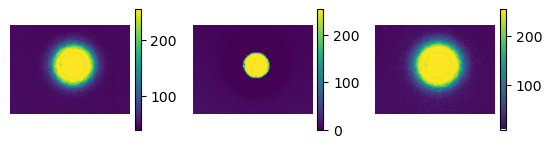

x_mean:  337.60701199798837   y_mean:  219.95028378475465  time: 0.0017
x_curve:  338.0741818324901   y_curve:  218.9196570198962  time: 0.49


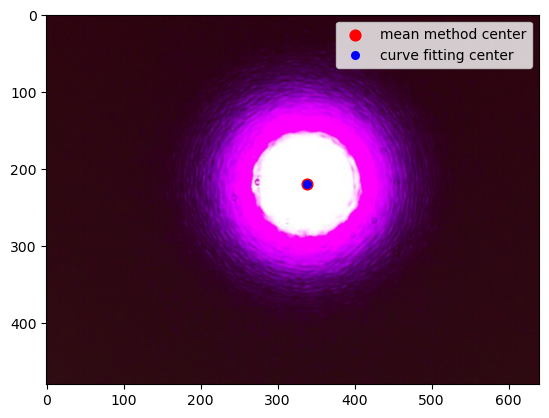

---------------------
3cm_from_mirror/gaussian_100uW.jpg


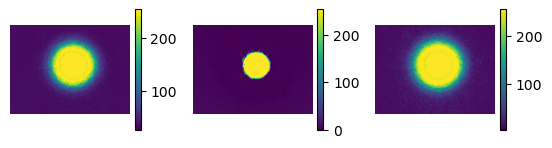

x_mean:  337.76839322801936   y_mean:  219.88658820567687  time: 0.0021
x_curve:  337.88484116592815   y_curve:  218.5292489124683  time: 0.39


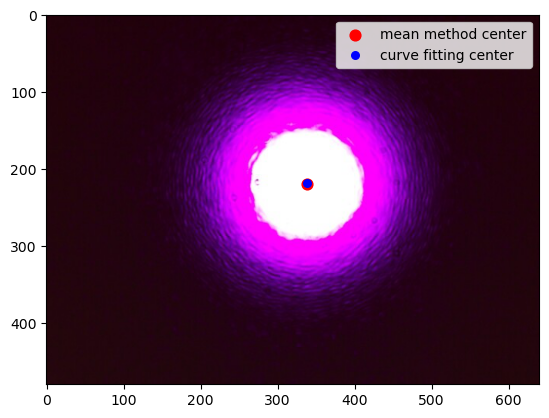

---------------------
3cm_from_mirror/gaussian_150uW.jpg


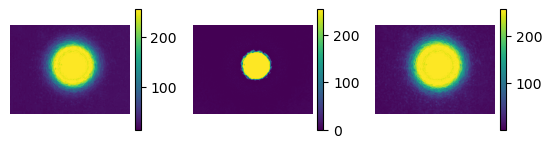

x_mean:  336.29215561593156   y_mean:  221.00635874906064  time: 0.0023
x_curve:  336.81643712027136   y_curve:  219.77919866928866  time: 0.48


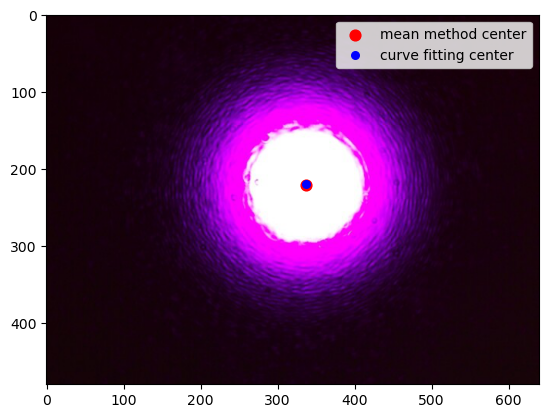

---------------------
3cm_from_mirror/gaussian_200uW.jpg


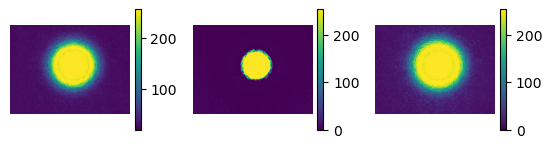

x_mean:  336.9375878093591   y_mean:  218.54301307683994  time: 0.0027
x_curve:  337.79893314482405   y_curve:  218.2780790346654  time: 0.53


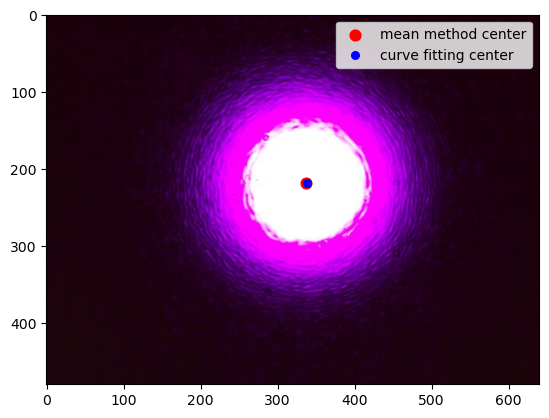

---------------------
3cm_from_mirror/gaussian_500uW.jpg


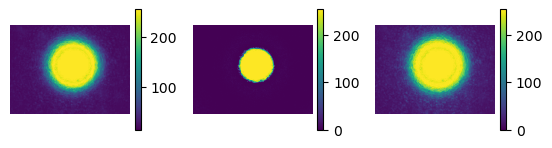

x_mean:  338.2447687779704   y_mean:  218.9710518888844  time: 0.0034
x_curve:  337.64992174178593   y_curve:  217.964948042302  time: 0.44


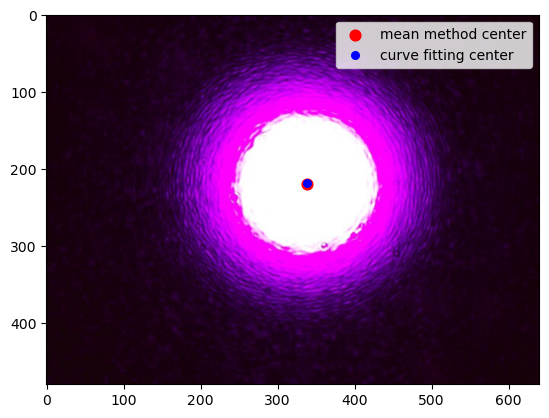

---------------------


In [14]:
img_path_list = [
    "gaussian_3uW.jpg",
    "gaussian_5uW.jpg",
    "gaussian_6uW.jpg",
    "gaussian_10uW.jpg",
    "gaussian_13uW.jpg",
    "gaussian_50uW.jpg",
    "gaussian_100uW.jpg",
    "gaussian_150uW.jpg",
    "gaussian_200uW.jpg",
    "gaussian_500uW.jpg"
]

# 3cm
for img_path in img_path_list:
    print(f"3cm_from_mirror/{img_path}")
    image = Image.open(f"6cm_from_mirror/{img_path}")
    image_array = np.array(image)
    plot_img(image_array=image_array)

    start_curve = time.perf_counter()
    x_curve, y_curve = curve_fitting(image_array=image_array)
    end_curve = time.perf_counter()

    start_mean = time.perf_counter()
    x_mean, y_mean = find_centre_gaus(image_array=image_array[:,:,1])
    end_mean = time.perf_counter()
    print("x_mean: ", x_mean, "  y_mean: ", y_mean, f" time: {end_mean - start_mean:.2}")
    print("x_curve: ", x_curve, "  y_curve: ", y_curve, f" time: {end_curve - start_curve:.2}")

    plt.imshow(image_array)
    plt.scatter(x_mean, y_mean, s=60, color="red", alpha=1, label="mean method center")
    plt.scatter(x_curve, y_curve, s=30, color="blue", alpha=1, label="curve fitting center")
    plt.legend()
    plt.show()
    print("---------------------")
    

In [ ]:
# Find centre over 1k images to find variances
import pandas as pd

index_range = range(1000)
clean_df = pd.DataFrame(index=index_range, columns=["x_mean", "y_mean", "x_curve", "y_curve"])

for index in index_range:
    image = Image.open(f'clean_signal_stream/image{index+1}.jpg')
    image_array = np.array(image)

    x_curve, y_curve = curve_fitting(image_array=image_array)

    imgR = image_array[:,:,0]
    imgG = image_array[:,:,1]
    imgB = image_array[:,:,2]
    image_array_greyscale = (0.7 * imgR) + (0.2 * imgG) + (0.1 * imgB)

    x_mean, y_mean = find_centre_gaus(image_array=image_array_greyscale)

    clean_df.loc[index, "x_curve"] = x_curve
    clean_df.loc[index, "y_curve"] = y_curve
    clean_df.loc[index, "x_mean"] = x_mean
    clean_df.loc[index, "y_mean"] = y_mean

    

In [40]:
# Find centre over 1k images to find variances
import pandas as pd

index_range = range(1000)
dirty_marker_df = pd.DataFrame(index=index_range, columns=["x_mean", "y_mean", "x_curve", "y_curve"])

for index in index_range:
    image = Image.open(f'dirty_signal_stream_marker/image{index+1}.jpg')
    image_array = np.array(image)

    x_curve, y_curve = curve_fitting(image_array=image_array)

    imgR = image_array[:,:,0]
    imgG = image_array[:,:,1]
    imgB = image_array[:,:,2]
    image_array_greyscale = (0.7 * imgR) + (0.2 * imgG) + (0.1 * imgB)

    x_mean, y_mean = find_centre_gaus(image_array=image_array_greyscale)

    dirty_marker_df.loc[index, "x_curve"] = x_curve
    dirty_marker_df.loc[index, "y_curve"] = y_curve
    dirty_marker_df.loc[index, "x_mean"] = x_mean
    dirty_marker_df.loc[index, "y_mean"] = y_mean
    

In [42]:
# Find centre over 1k images to find variances
import pandas as pd

index_range = range(1000)
dirty_smudge_df = pd.DataFrame(index=index_range, columns=["x_mean", "y_mean", "x_curve", "y_curve"])

for index in index_range:
    image = Image.open(f'dirty_signal_stream_smudge/image{index+1}.jpg')
    image_array = np.array(image)

    x_curve, y_curve = curve_fitting(image_array=image_array)

    imgR = image_array[:,:,0]
    imgG = image_array[:,:,1]
    imgB = image_array[:,:,2]
    image_array_greyscale = (0.7 * imgR) + (0.2 * imgG) + (0.1 * imgB)

    x_mean, y_mean = find_centre_gaus(image_array=image_array_greyscale)

    dirty_smudge_df.loc[index, "x_curve"] = x_curve
    dirty_smudge_df.loc[index, "y_curve"] = y_curve
    dirty_smudge_df.loc[index, "x_mean"] = x_mean
    dirty_smudge_df.loc[index, "y_mean"] = y_mean


x_mean      0.03805
y_mean     0.045397
x_curve    0.014038
y_curve    0.007017
dtype: object

In [45]:
clean_df.to_csv("clean.csv")
clean_df.var()

x_mean     0.007195
y_mean     0.009746
x_curve    0.012565
y_curve     0.00442
dtype: object

In [43]:
dirty_marker_df.to_csv("dirty_marker.csv")
dirty_marker_df.var()

x_mean     0.017481
y_mean     0.030602
x_curve    0.036022
y_curve    0.005005
dtype: object

In [44]:
dirty_smudge_df.to_csv("dirty_smudge.csv")
dirty_smudge_df.var()

x_mean      0.03805
y_mean     0.045397
x_curve    0.014038
y_curve    0.007017
dtype: object

Text(0, 0.5, 'Var (pixels)')

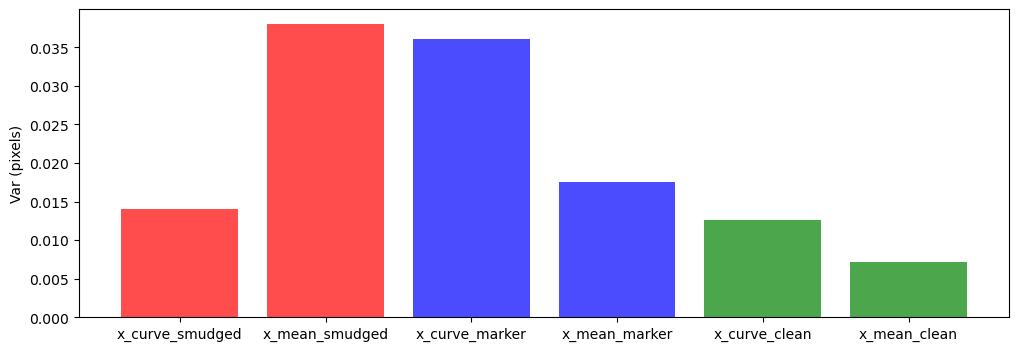

In [76]:
categories = [
    "x_curve_smudged", 
    "x_mean_smudged", 
    "x_curve_marker", 
    "x_mean_marker",
    "x_curve_clean", 
    "x_mean_clean",
]

data = [
    dirty_smudge_df.var()["x_curve"],
    dirty_smudge_df.var()["x_mean"],
    dirty_marker_df.var()["x_curve"],
    dirty_marker_df.var()["x_mean"],
    clean_df.var()["x_curve"],
    clean_df.var()["x_mean"]
]

labels = ["smudged", "smudged", "marker", "marker", "clean", "clean"]

plt.figure(figsize=(12,4))
colors = ["red", "red", "blue", "blue", "green", "green"]

for i in range(len(categories)):
    plt.bar(categories[i], data[i], color=colors[i], label=labels[i], alpha=0.7)

plt.ylabel("Var (pixels)")

Text(0, 0.5, 'Var (pixels)')

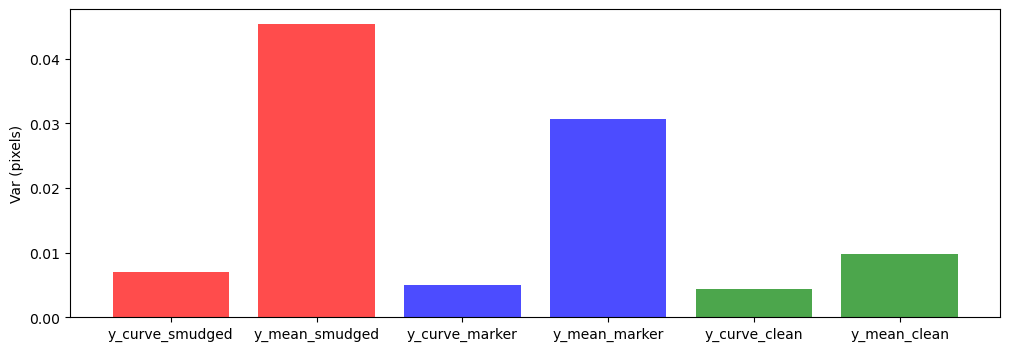

In [73]:
categories = [
    "y_curve_smudged", 
    "y_mean_smudged", 
    "y_curve_marker", 
    "y_mean_marker",
    "y_curve_clean", 
    "y_mean_clean",
]

data = [
    dirty_smudge_df.var()["y_curve"],
    dirty_smudge_df.var()["y_mean"],
    dirty_marker_df.var()["y_curve"],
    dirty_marker_df.var()["y_mean"],
    clean_df.var()["y_curve"],
    clean_df.var()["y_mean"]
]

labels = ["smudged", "smudged", "marker", "marker", "clean", "clean"]

plt.figure(figsize=(12,4))
colors = ["red", "red", "blue", "blue", "green", "green"]

for i in range(len(categories)):
    plt.bar(categories[i], data[i], color=colors[i], label=labels[i], alpha=0.7)

plt.ylabel("Var (pixels)")

In [82]:
# Find centre over 1k images to find variances
import pandas as pd

index_range = range(1000)
dirty_smudge_alt_df = pd.DataFrame(index=index_range, columns=["y_mean", "y_curve"])

for index in index_range:
    image = Image.open(f'dirty_signal_stream_smudge/image{index+1}.jpg')
    image_array = np.rot90(np.array(image))

    x_curve, y_curve = curve_fitting(image_array=image_array)

    imgR = image_array[:,:,0]
    imgG = image_array[:,:,1]
    imgB = image_array[:,:,2]
    image_array_greyscale = (0.7 * imgR) + (0.2 * imgG) + (0.1 * imgB)

    x_mean, y_mean = find_centre_gaus(image_array=image_array_greyscale)

    dirty_smudge_alt_df.loc[index, "y_curve"] = x_curve
    dirty_smudge_alt_df.loc[index, "y_mean"] = x_mean

In [83]:
dirty_smudge_alt_df.to_csv("dirty_smudge_alt.csv")
dirty_smudge_alt_df.var()

y_mean     0.045397
y_curve    0.007017
dtype: object

In [84]:
# Find centre over 1k images to find variances
import pandas as pd

index_range = range(1000)
dirty_marker_alt_df = pd.DataFrame(index=index_range, columns=["y_mean", "y_curve"])

for index in index_range:
    image = Image.open(f'dirty_signal_stream_smudge/image{index+1}.jpg')
    image_array = np.rot90(np.array(image))

    x_curve, y_curve = curve_fitting(image_array=image_array)

    imgR = image_array[:,:,0]
    imgG = image_array[:,:,1]
    imgB = image_array[:,:,2]
    image_array_greyscale = (0.7 * imgR) + (0.2 * imgG) + (0.1 * imgB)

    x_mean, y_mean = find_centre_gaus(image_array=image_array_greyscale)

    dirty_marker_alt_df.loc[index, "y_curve"] = x_curve
    dirty_marker_alt_df.loc[index, "y_mean"] = x_mean

dirty_marker_alt_df.to_csv("dirty_marker_alt.csv")
dirty_marker_alt_df.var()

y_mean     0.045397
y_curve    0.007017
dtype: object

In [85]:
# Find centre over 1k images to find variances
import pandas as pd

index_range = range(1000)
clean_alt_df = pd.DataFrame(index=index_range, columns=["y_mean", "y_curve"])

for index in index_range:
    image = Image.open(f'dirty_signal_stream_smudge/image{index+1}.jpg')
    image_array = np.rot90(np.array(image))

    x_curve, y_curve = curve_fitting(image_array=image_array)

    imgR = image_array[:,:,0]
    imgG = image_array[:,:,1]
    imgB = image_array[:,:,2]
    image_array_greyscale = (0.7 * imgR) + (0.2 * imgG) + (0.1 * imgB)

    x_mean, y_mean = find_centre_gaus(image_array=image_array_greyscale)

    clean_alt_df.loc[index, "y_curve"] = x_curve
    clean_alt_df.loc[index, "y_mean"] = x_mean

clean_alt_df.to_csv("clean_alt.csv")
clean_alt_df.var()

y_mean     0.045397
y_curve    0.007017
dtype: object

Text(0.5, 1.0, 'Using Rot90 to find y')

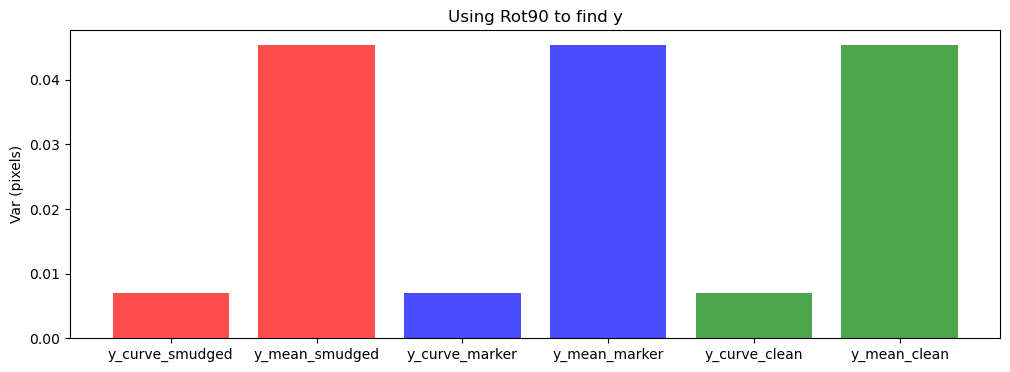

In [86]:
categories = [
    "y_curve_smudged", 
    "y_mean_smudged", 
    "y_curve_marker", 
    "y_mean_marker",
    "y_curve_clean", 
    "y_mean_clean",
]

data = [
    dirty_smudge_alt_df.var()["y_curve"],
    dirty_smudge_alt_df.var()["y_mean"],
    dirty_marker_alt_df.var()["y_curve"],
    dirty_marker_alt_df.var()["y_mean"],
    clean_alt_df.var()["y_curve"],
    clean_alt_df.var()["y_mean"]
]

labels = ["smudged", "smudged", "marker", "marker", "clean", "clean"]

plt.figure(figsize=(12,4))
colors = ["red", "red", "blue", "blue", "green", "green"]

for i in range(len(categories)):
    plt.bar(categories[i], data[i], color=colors[i], label=labels[i], alpha=0.7)

plt.ylabel("Var (pixels)")
plt.title("Using Rot90 to find y")

# Bootstrapping method

In [ ]:
# Find centre over 1k images to find variances
import pandas as pd

bootstrap_sample_size = 200
index_range = range(bootstrap_sample_size)
clean_df = pd.DataFrame(index=index_range, columns=["y_mean", "y_curve"])
clean_var_list = []
clean_mean_list = []

for j in range(5):
    index_list = np.random.randint(low=0, high=1000, size=bootstrap_sample_size)
    i = 0
    for index in index_list:
        image = Image.open(f'clean_signal_stream/image{index+1}.jpg')

        x_curve, y_curve = curve_fitting(image_array=image_array)

        imgR = image_array[:,:,0]
        imgG = image_array[:,:,1]
        imgB = image_array[:,:,2]
        image_array_greyscale = (0.7 * imgR) + (0.2 * imgG) + (0.1 * imgB)

        x_mean, y_mean = find_centre_gaus(image_array=image_array_greyscale)

        clean_df.loc[i, "x_curve"] = x_curve
        clean_df.loc[i, "x_mean"] = x_mean
        clean_df.loc[i, "y_curve"] = y_curve
        clean_df.loc[i, "y_mean"] = y_mean
        i+=1

    clean_var_list.append(clean_df.var())
    clean_mean_list.append(clean_df.mean())

clean_var_df = pd.DataFrame(clean_var_list)
clean_mean_df = pd.DataFrame(clean_mean_list)



In [ ]:
# Find centre over 1k images to find variances
import pandas as pd

bootstrap_sample_size = 200
index_range = range(bootstrap_sample_size)
dirty_marker_df = pd.DataFrame(index=index_range, columns=["y_mean", "y_curve"])
dirty_marker_var_list = []
dirty_marker_mean_list = []

for j in range(5):
    index_list = np.random.randint(low=0, high=1000, size=bootstrap_sample_size)
    i = 0
    for index in index_list:
        image = Image.open(f'dirty_signal_stream_marker/image{index+1}.jpg')

        x_curve, y_curve = curve_fitting(image_array=image_array)

        imgR = image_array[:,:,0]
        imgG = image_array[:,:,1]
        imgB = image_array[:,:,2]
        image_array_greyscale = (0.7 * imgR) + (0.2 * imgG) + (0.1 * imgB)

        x_mean, y_mean = find_centre_gaus(image_array=image_array_greyscale)

        dirty_marker_df.loc[i, "x_curve"] = x_curve
        dirty_marker_df.loc[i, "x_mean"] = x_mean
        dirty_marker_df.loc[i, "y_curve"] = y_curve
        dirty_marker_df.loc[i, "y_mean"] = y_mean
        i+=1

    dirty_marker_var_list.append(dirty_marker_df.var())
    dirty_marker_mean_list.append(dirty_marker_df.mean())

dirty_marker_var_df = pd.DataFrame(dirty_marker_var_list)
dirty_marker_mean_df = pd.DataFrame(dirty_marker_mean_list)

In [ ]:
# Find centre over 1k images to find variances
import pandas as pd

bootstrap_sample_size = 200
index_range = range(bootstrap_sample_size)
dirty_smudge_df = pd.DataFrame(index=index_range, columns=["y_mean", "y_curve"])
dirty_smudge_var_list = []
dirty_smudge_mean_list = []

for j in range(5):
    index_list = np.random.randint(low=0, high=1000, size=bootstrap_sample_size)
    i = 0
    for index in index_list:
        image = Image.open(f'dirty_signal_stream_smudge/image{index+1}.jpg')

        x_curve, y_curve = curve_fitting(image_array=image_array)

        imgR = image_array[:,:,0]
        imgG = image_array[:,:,1]
        imgB = image_array[:,:,2]
        image_array_greyscale = (0.7 * imgR) + (0.2 * imgG) + (0.1 * imgB)

        x_mean, y_mean = find_centre_gaus(image_array=image_array_greyscale)

        dirty_smudge_df.loc[i, "x_curve"] = x_curve
        dirty_smudge_df.loc[i, "x_mean"] = x_mean
        dirty_smudge_df.loc[i, "y_curve"] = y_curve
        dirty_smudge_df.loc[i, "y_mean"] = y_mean
        i+=1

    dirty_smudge_var_list.append(dirty_smudge_df.var())
    dirty_smudge_mean_list.append(dirty_smudge_df.mean())

dirty_smudge_var_df = pd.DataFrame(dirty_smudge_var_list)
dirty_smudge_mean_df = pd.DataFrame(dirty_smudge_mean_list)

Text(0.5, 1.0, 'Using Bootstrapping to find y')

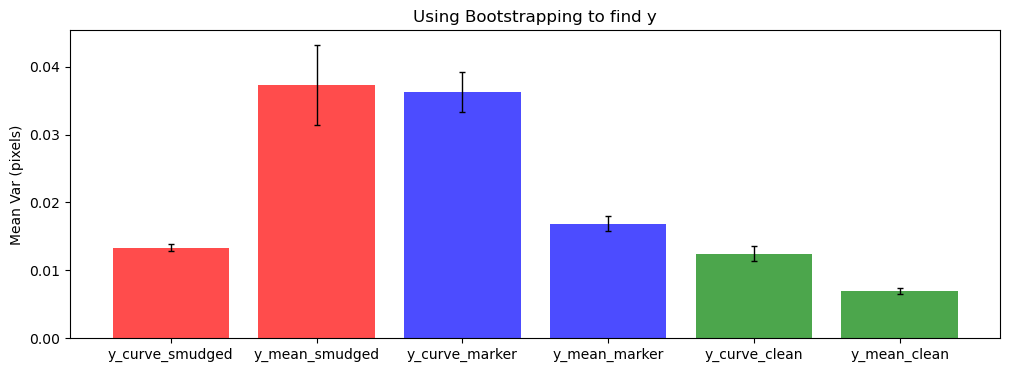

In [116]:
categories = [
    "y_curve_smudged", 
    "y_mean_smudged", 
    "y_curve_marker", 
    "y_mean_marker",
    "y_curve_clean", 
    "y_mean_clean",
]

data = [
    dirty_smudge_var_df["y_curve"].mean(),
    dirty_smudge_var_df["y_mean"].mean(),
    dirty_marker_var_df["y_curve"].mean(),
    dirty_marker_var_df["y_mean"].mean(),
    clean_var_df["y_curve"].mean(),
    clean_var_df["y_mean"].mean()
]

std_devs = [
    dirty_smudge_var_df["y_curve"].std(),
    dirty_smudge_var_df["y_mean"].std(),
    dirty_marker_var_df["y_curve"].std(),
    dirty_marker_var_df["y_mean"].std(),
    clean_var_df["y_curve"].std(),
    clean_var_df["y_mean"].std()
]

labels = ["smudged", "smudged", "marker", "marker", "clean", "clean"]

plt.figure(figsize=(12,4))
colors = ["red", "red", "blue", "blue", "green", "green"]

for i in range(len(categories)):
    plt.bar(categories[i], data[i], color=colors[i], label=labels[i], alpha=0.7, yerr=std_devs[i], error_kw={
        'ecolor': 'black',           # Color of the error bar
        'elinewidth': 1,             # Thickness of the vertical line
        'capthick': 1,                # Thickness of the cap horizontal line
        'capsize': 2
    })

plt.ylabel("Mean Var (pixels)")
plt.title("Using Bootstrapping to find y")

Text(0.5, 1.0, 'Using Bootstrapping to find x')

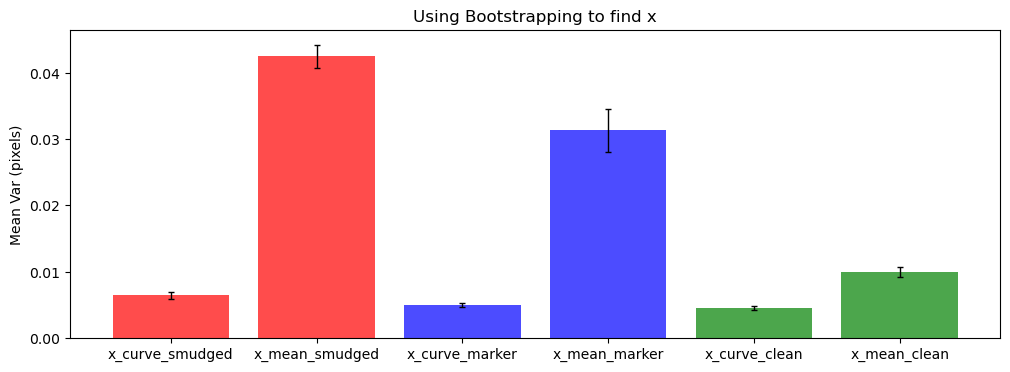

In [118]:
categories = [
    "x_curve_smudged", 
    "x_mean_smudged", 
    "x_curve_marker", 
    "x_mean_marker",
    "x_curve_clean", 
    "x_mean_clean",
]

data = [
    dirty_smudge_var_df["x_curve"].mean(),
    dirty_smudge_var_df["x_mean"].mean(),
    dirty_marker_var_df["x_curve"].mean(),
    dirty_marker_var_df["x_mean"].mean(),
    clean_var_df["x_curve"].mean(),
    clean_var_df["x_mean"].mean()
]

std_devs = [
    dirty_smudge_var_df["x_curve"].std(),
    dirty_smudge_var_df["x_mean"].std(),
    dirty_marker_var_df["x_curve"].std(),
    dirty_marker_var_df["x_mean"].std(),
    clean_var_df["x_curve"].std(),
    clean_var_df["x_mean"].std()
]

labels = ["smudged", "smudged", "marker", "marker", "clean", "clean"]

plt.figure(figsize=(12,4))
colors = ["red", "red", "blue", "blue", "green", "green"]

for i in range(len(categories)):
    plt.bar(categories[i], data[i], color=colors[i], label=labels[i], alpha=0.7, yerr=std_devs[i], error_kw={
        'ecolor': 'black',           # Color of the error bar
        'elinewidth': 1,             # Thickness of the vertical line
        'capthick': 1,                # Thickness of the cap horizontal line
        'capsize': 2
    })

plt.ylabel("Mean Var (pixels)")
plt.title("Using Bootstrapping to find x")